In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import pickle, json, time, random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))
device = "cuda" if torch.cuda.is_available() else "cpu"
print("using device:", device)

INTERIM_PATH = "/kaggle/input/datasets/anurajgogoi/cineiq-interim-files/interim"

ratings_train = pd.read_parquet(f"{INTERIM_PATH}/ratings_train.parquet")
warm_users = set(pd.read_parquet(f"{INTERIM_PATH}/warm_users.parquet")["userId"])
ratings_val_warm = pd.read_parquet(f"{INTERIM_PATH}/ratings_val_warm.parquet")

ratings_train_warm = ratings_train[ratings_train["userId"].isin(warm_users)]
print("ratings_train_warm shape:", ratings_train_warm.shape)
print("warm users:", len(warm_users))

CUDA available: True
device name: Tesla T4
using device: cuda
ratings_train_warm shape: (20462986, 6)
warm users: 126591


In [2]:
# Build movie ID mapping + encoded sequences (full scale)

def build_movie_id_mapping(ratings_train, item_col="movieId"):
    unique_movies = sorted(ratings_train[item_col].unique())
    movie_to_idx = {movie_id: idx + 1 for idx, movie_id in enumerate(unique_movies)}  # +1 reserves 0 for padding
    idx_to_movie = {idx: movie_id for movie_id, idx in movie_to_idx.items()}
    return movie_to_idx, idx_to_movie

def build_sequences_encoded(ratings_train, movie_to_idx, user_col="userId",
                             item_col="movieId", timestamp_col="timestamp", max_seq_len=100):
    sorted_ratings = ratings_train.sort_values([user_col, timestamp_col])
    sequences = {}
    for user_id, group in sorted_ratings.groupby(user_col):
        movie_ids = group[item_col].tolist()
        encoded = [movie_to_idx[m] for m in movie_ids]
        if len(encoded) > max_seq_len:
            encoded = encoded[-max_seq_len:]  # keep most recent
        sequences[user_id] = encoded
    return sequences

start = time.time()
movie_to_idx, idx_to_movie = build_movie_id_mapping(ratings_train_warm)
vocab_size = len(movie_to_idx) + 1
print("vocab size (incl. padding):", vocab_size)

sequences = build_sequences_encoded(ratings_train_warm, movie_to_idx, max_seq_len=100)
print("number of user sequences:", len(sequences))
print(f"built in {time.time()-start:.1f}s")

lengths = [len(s) for s in sequences.values()]
print("\nsequence length stats (post-cap):")
print(pd.Series(lengths).describe())

vocab size (incl. padding): 37335
number of user sequences: 126591
built in 22.1s

sequence length stats (post-cap):
count    126591.000000
mean         72.291593
std          28.609482
min          25.000000
25%          43.000000
50%          80.000000
75%         100.000000
max         100.000000
dtype: float64


In [3]:
# CELL 3 — Datasets (single-position and multi-position) + collate function

class SequenceDataset(Dataset):
    """One example per user: predict the LAST item from everything before it."""
    def __init__(self, sequences: dict, min_len: int = 2):
        self.examples = []
        for user_id, seq in sequences.items():
            if len(seq) >= min_len:
                self.examples.append((seq[:-1], seq[-1]))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        input_seq, target = self.examples[idx]
        return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target, dtype=torch.long)


class SequenceDatasetMultiPos(Dataset):
    """
    Multiple examples per user: every prefix -> next-item pair, up to
    max_examples_per_user positions sampled uniformly at random (with a
    fixed random_state for reproducibility of WHICH positions are chosen —
    note this does not make model training itself deterministic unless
    set_seed() has also been called, since model init/dropout/shuffle also
    involve randomness).
    """
    def __init__(self, sequences: dict, min_len: int = 2, max_examples_per_user: int = 20,
                 random_state: int = 42):
        rng = np.random.RandomState(random_state)
        self.examples = []
        for user_id, seq in sequences.items():
            if len(seq) < min_len:
                continue
            valid_positions = list(range(1, len(seq)))
            if max_examples_per_user is not None and len(valid_positions) > max_examples_per_user:
                valid_positions = sorted(
                    rng.choice(valid_positions, size=max_examples_per_user, replace=False)
                )
            for i in valid_positions:
                self.examples.append((seq[:i], seq[i]))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        input_seq, target = self.examples[idx]
        return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target, dtype=torch.long)


def collate_fn(batch):
    input_seqs, targets = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in input_seqs])
    padded_inputs = pad_sequence(input_seqs, batch_first=True, padding_value=0)
    targets = torch.stack(targets)
    return padded_inputs, lengths, targets

In [4]:
# CELL 4 — Validation-loss eval set (held out, used to track generalization every epoch)

def build_val_loss_examples(sequences_train, ratings_val_warm, movie_to_idx,
                             user_col="userId", item_col="movieId", timestamp_col="timestamp"):
    """(full train sequence -> true first val movie) pairs, encoded — used
    ONLY to measure validation loss during training, never for training itself."""
    first_val = ratings_val_warm.sort_values(timestamp_col).groupby(user_col).head(1)
    examples = []
    for _, row in first_val.iterrows():
        user_id, true_movie = row[user_col], row[item_col]
        if user_id in sequences_train and true_movie in movie_to_idx:
            examples.append((sequences_train[user_id], movie_to_idx[true_movie]))
    return examples

def compute_val_loss(model, val_examples, device="cpu", batch_size=256):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, n = 0.0, 0
    with torch.no_grad():
        for i in range(0, len(val_examples), batch_size):
            batch = val_examples[i:i+batch_size]
            seqs = [torch.tensor(s, dtype=torch.long) for s, _ in batch]
            targets = torch.tensor([t for _, t in batch], dtype=torch.long).to(device)
            lengths = torch.tensor([len(s) for s in seqs])
            padded = pad_sequence(seqs, batch_first=True, padding_value=0).to(device)
            logits = model(padded, lengths)
            loss = criterion(logits, targets)
            total_loss += loss.item() * len(batch)
            n += len(batch)
    model.train()
    return total_loss / n

val_loss_examples = build_val_loss_examples(sequences, ratings_val_warm, movie_to_idx)
print("val loss eval examples:", len(val_loss_examples))

val loss eval examples: 5118


In [5]:
# CELL 5 — Model classes: base GRU4Rec (v1/v2) and tied-weight GRU4Rec (v5/v6)

class GRU4RecBase(nn.Module):
    """Plain GRU4Rec: embedding -> GRU -> untied Linear output layer.
    No dropout (num_layers=1 makes nn.GRU's dropout param a no-op)."""
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers=1, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_seqs, lengths):
        embedded = self.embedding(input_seqs)
        packed = nn.utils.rnn.pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(packed)
        logits = self.output_layer(hidden[-1])
        return logits


class GRU4RecTied(nn.Module):
    """
    Regularized, weight-tied GRU4Rec (spec for v5/v6):
    - dropout on embeddings + pre-output (works regardless of num_layers)
    - output layer TIED to the embedding matrix (dot product + bias)
      instead of a separate ~4.78M-param Linear layer -> ~65% fewer params
    - embed_sequence()/score_full_vocab()/score_items() are split out so
      the same class supports both full-softmax cross-entropy training
      (v5) and BPR negative-sampling training (v6) without duplicating
      the architecture.
    """
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding_dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers=1, batch_first=True)
        self.output_dropout = nn.Dropout(dropout)
        self.projection = nn.Identity() if hidden_dim == embedding_dim else nn.Linear(hidden_dim, embedding_dim)
        self.output_bias = nn.Parameter(torch.zeros(vocab_size))

    def embed_sequence(self, input_seqs, lengths):
        embedded = self.embedding_dropout(self.embedding(input_seqs))
        packed = nn.utils.rnn.pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(packed)
        return self.projection(self.output_dropout(hidden[-1]))  # [batch, embedding_dim]

    def score_full_vocab(self, projected):
        return projected @ self.embedding.weight.T + self.output_bias  # [batch, vocab_size]

    def score_items(self, projected, item_idx):
        item_emb = self.embedding(item_idx)
        item_bias = self.output_bias[item_idx]
        if item_idx.dim() == 1:
            return (projected * item_emb).sum(-1) + item_bias
        return torch.einsum("bd,bnd->bn", projected, item_emb) + item_bias

    def forward(self, input_seqs, lengths):
        return self.score_full_vocab(self.embed_sequence(input_seqs, lengths))

In [6]:
# CELL 6 — Training loops (with per-epoch loss history for plotting) + evaluation functions

def train_gru_full(model, train_loader, val_examples, num_epochs=10, lr=0.001,
                    weight_decay=0.0, patience=None, device="cpu", verbose=True):
    """
    Unified cross-entropy training loop used for v1, v2, and v5.
    Records train/val loss every epoch (history) for plotting.
    If patience is set, stops early on val-loss plateau and restores the
    best-val-loss checkpoint. If patience is None, trains for the full
    num_epochs and keeps the FINAL epoch's weights (used for v1/v2, to
    faithfully reproduce the original "no early stopping" experiments).
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    epochs_without_improvement = 0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        total_loss, num_batches = 0.0, 0
        epoch_start = time.time()

        for batch_inputs, batch_lengths, batch_targets in train_loader:
            batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)
            optimizer.zero_grad()
            logits = model(batch_inputs, batch_lengths)
            loss = criterion(logits, batch_targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            num_batches += 1

        train_loss = total_loss / num_batches
        val_loss = compute_val_loss(model, val_examples, device=device)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if verbose:
            print(f"epoch {epoch+1}/{num_epochs} — train loss: {train_loss:.4f} — "
                  f"val loss: {val_loss:.4f} — {time.time()-epoch_start:.1f}s")

        if patience is not None:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_without_improvement = 0
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement >= patience:
                    print(f"\nearly stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                    break

    if patience is not None and best_state is not None:
        model.load_state_dict(best_state)
        print(f"restored best model — val loss: {best_val_loss:.4f}")

    return model, history


def sample_negatives(batch_size, num_negatives, vocab_size, device="cpu"):
    """Uniform random negative movie indices (excludes padding index 0)."""
    return torch.randint(1, vocab_size, (batch_size, num_negatives), device=device)


def bpr_loss(model, projected, pos_idx, neg_idx):
    pos_score = model.score_items(projected, pos_idx)
    neg_score = model.score_items(projected, neg_idx)
    diff = pos_score.unsqueeze(1) - neg_score
    return -torch.log(torch.sigmoid(diff) + 1e-10).mean()


def train_gru_bpr_full(model, train_loader, val_examples, vocab_size, num_epochs=30,
                        lr=0.001, weight_decay=1e-5, num_negatives=50, patience=3, device="cpu"):
    """
    BPR + negative sampling training loop (v6). Train loss is on the BPR
    scale (NOT comparable to cross-entropy train loss) — val loss is still
    computed via cross-entropy for apples-to-apples comparison against
    v1/v2/v5.
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    epochs_without_improvement = 0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        total_loss, num_batches = 0.0, 0
        epoch_start = time.time()

        for batch_inputs, batch_lengths, batch_targets in train_loader:
            batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)
            batch_size = batch_inputs.size(0)
            optimizer.zero_grad()
            projected = model.embed_sequence(batch_inputs, batch_lengths)
            neg_idx = sample_negatives(batch_size, num_negatives, vocab_size, device=device)
            loss = bpr_loss(model, projected, batch_targets, neg_idx)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            num_batches += 1

        train_loss = total_loss / num_batches
        val_loss = compute_val_loss(model, val_examples, device=device)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"epoch {epoch+1}/{num_epochs} — BPR train loss: {train_loss:.4f} — "
              f"val loss (CE): {val_loss:.4f} — {time.time()-epoch_start:.1f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"\nearly stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

    model.load_state_dict(best_state)
    print(f"restored best model — val loss: {best_val_loss:.4f}")
    return model, history


def predict_top_k_gru(model, sequence, k=10, device="cpu"):
    model.eval()
    with torch.no_grad():
        input_tensor = torch.tensor([sequence], dtype=torch.long).to(device)
        length_tensor = torch.tensor([len(sequence)])
        logits = model(input_tensor, length_tensor)
        return torch.topk(logits, k=k, dim=1).indices[0].tolist()


def evaluate_gru(model, sequences, ratings_val_warm, movie_to_idx, idx_to_movie, k=10, device="cpu",
                  user_col="userId", item_col="movieId", timestamp_col="timestamp"):
    first_val = (ratings_val_warm.sort_values(timestamp_col).groupby(user_col).head(1)
                 [[user_col, item_col]].rename(columns={item_col: "true_next_movie"}))
    hits, ndcgs, n_evaluated = 0, [], 0
    for _, row in first_val.iterrows():
        user_id, true_movie = row[user_col], row["true_next_movie"]
        if user_id not in sequences or true_movie not in movie_to_idx:
            continue
        top_k_idxs = predict_top_k_gru(model, sequences[user_id], k=k, device=device)
        top_k_movies = [idx_to_movie[i] for i in top_k_idxs]
        n_evaluated += 1
        if true_movie in top_k_movies:
            hits += 1
            ndcgs.append(1.0 / np.log2(top_k_movies.index(true_movie) + 2))
        else:
            ndcgs.append(0.0)
    hit_rate = hits / n_evaluated if n_evaluated else 0.0
    ndcg = np.mean(ndcgs) if ndcgs else 0.0
    return hit_rate, ndcg, n_evaluated

In [24]:
# CELL — predict_top_k with seen-item masking

def predict_top_k_gru_masked(model, sequence, k=10, device="cpu"):
    """
    Same as predict_top_k_gru, but excludes movies already in the user's
    sequence from the top-k results — a recommender shouldn't re-suggest
    something the user just watched.
    """
    model.eval()
    with torch.no_grad():
        input_tensor = torch.tensor([sequence], dtype=torch.long).to(device)
        length_tensor = torch.tensor([len(sequence)])
        logits = model(input_tensor, length_tensor).clone()

        seen = torch.tensor(list(set(sequence)), dtype=torch.long, device=device)
        logits[0, seen] = -float("inf")  # exclude already-watched movies

        top_k_indices = torch.topk(logits, k=k, dim=1).indices[0].tolist()
    return top_k_indices

# CELL — Evaluate v5 with seen-item masking applied

def evaluate_gru_masked(model, sequences, ratings_val_warm, movie_to_idx, idx_to_movie, k=10, device="cpu",
                         user_col="userId", item_col="movieId", timestamp_col="timestamp"):
    first_val = (ratings_val_warm.sort_values(timestamp_col).groupby(user_col).head(1)
                 [[user_col, item_col]].rename(columns={item_col: "true_next_movie"}))
    hits, ndcgs, n_evaluated = 0, [], 0
    for _, row in first_val.iterrows():
        user_id, true_movie = row[user_col], row["true_next_movie"]
        if user_id not in sequences or true_movie not in movie_to_idx:
            continue
        top_k_idxs = predict_top_k_gru_masked(model, sequences[user_id], k=k, device=device)
        top_k_movies = [idx_to_movie[i] for i in top_k_idxs]
        n_evaluated += 1
        if true_movie in top_k_movies:
            hits += 1
            ndcgs.append(1.0 / np.log2(top_k_movies.index(true_movie) + 2))
        else:
            ndcgs.append(0.0)
    hit_rate = hits / n_evaluated if n_evaluated else 0.0
    ndcg = np.mean(ndcgs) if ndcgs else 0.0
    return hit_rate, ndcg, n_evaluated


hr10_v5_masked, ndcg10_v5_masked, n_eval_masked = evaluate_gru_masked(
    model_v5, sequences, ratings_val_warm, movie_to_idx, idx_to_movie, device=device
)
print(f"v5 (masked) Hit Rate@10: {hr10_v5_masked:.4f}   NDCG@10: {ndcg10_v5_masked:.4f}")
print(f"v5 (unmasked, original) Hit Rate@10: {hr10_v5:.4f}   NDCG@10: {ndcg10_v5:.4f}")

v5 (masked) Hit Rate@10: 0.0514   NDCG@10: 0.0256
v5 (unmasked, original) Hit Rate@10: 0.0371   NDCG@10: 0.0179


In [7]:
# CELL 7 — Train + evaluate v1

set_seed(42)
dataset_v1 = SequenceDataset(sequences)
train_loader_v1 = DataLoader(dataset_v1, batch_size=256, shuffle=True, collate_fn=collate_fn)
print("v1 dataset size:", len(dataset_v1))

model_v1 = GRU4RecBase(vocab_size=vocab_size, embedding_dim=64, hidden_dim=128)
params_v1 = sum(p.numel() for p in model_v1.parameters())
print("v1 params:", f"{params_v1:,}")

start = time.time()
model_v1, history_v1 = train_gru_full(
    model_v1, train_loader_v1, val_loss_examples,
    num_epochs=10, lr=0.001, weight_decay=0.0, patience=None, device=device
)
print(f"\nv1 training time: {time.time()-start:.1f}s")

hr10_v1, ndcg10_v1, n_eval_v1 = evaluate_gru(model_v1, sequences, ratings_val_warm, movie_to_idx, idx_to_movie, device=device)
print(f"\nv1 Hit Rate@10: {hr10_v1:.4f}   NDCG@10: {ndcg10_v1:.4f}   (evaluated on {n_eval_v1} users)")
print(f"v1 final train loss: {history_v1['train_loss'][-1]:.4f}   final val loss: {history_v1['val_loss'][-1]:.4f}")

v1 dataset size: 126591
v1 params: 7,280,151
epoch 1/10 — train loss: 8.3649 — val loss: 8.8019 — 9.6s
epoch 2/10 — train loss: 7.5737 — val loss: 8.6029 — 8.8s
epoch 3/10 — train loss: 7.1546 — val loss: 8.5407 — 8.9s
epoch 4/10 — train loss: 6.7847 — val loss: 8.6271 — 9.2s
epoch 5/10 — train loss: 6.4371 — val loss: 8.7410 — 8.9s
epoch 6/10 — train loss: 6.1102 — val loss: 8.8784 — 8.9s
epoch 7/10 — train loss: 5.8019 — val loss: 9.0686 — 8.9s
epoch 8/10 — train loss: 5.5149 — val loss: 9.2156 — 9.3s
epoch 9/10 — train loss: 5.2498 — val loss: 9.3867 — 9.0s
epoch 10/10 — train loss: 5.0074 — val loss: 9.5705 — 9.1s

v1 training time: 94.2s

v1 Hit Rate@10: 0.0270   NDCG@10: 0.0134   (evaluated on 5118 users)
v1 final train loss: 5.0074   final val loss: 9.5705


In [8]:
# CELL 8 — Train + evaluate v2

set_seed(42)
dataset_v2 = SequenceDatasetMultiPos(sequences, max_examples_per_user=20)
train_loader_v2 = DataLoader(dataset_v2, batch_size=256, shuffle=True, collate_fn=collate_fn)
print("v2 dataset size:", len(dataset_v2), f"({len(dataset_v2)/len(dataset_v1):.1f}x v1)")

model_v2 = GRU4RecBase(vocab_size=vocab_size, embedding_dim=64, hidden_dim=128)
params_v2 = sum(p.numel() for p in model_v2.parameters())

start = time.time()
model_v2, history_v2 = train_gru_full(
    model_v2, train_loader_v2, val_loss_examples,
    num_epochs=5, lr=0.001, weight_decay=0.0, patience=None, device=device
)
print(f"\nv2 training time: {time.time()-start:.1f}s")

hr10_v2, ndcg10_v2, n_eval_v2 = evaluate_gru(model_v2, sequences, ratings_val_warm, movie_to_idx, idx_to_movie, device=device)
print(f"\nv2 Hit Rate@10: {hr10_v2:.4f}   NDCG@10: {ndcg10_v2:.4f}   (evaluated on {n_eval_v2} users)")
print(f"v2 final train loss: {history_v2['train_loss'][-1]:.4f}   final val loss: {history_v2['val_loss'][-1]:.4f}")

v2 dataset size: 2531820 (20.0x v1)
epoch 1/5 — train loss: 6.4283 — val loss: 8.9265 — 164.6s
epoch 2/5 — train loss: 5.8731 — val loss: 8.9686 — 163.3s
epoch 3/5 — train loss: 5.7155 — val loss: 9.0148 — 165.0s
epoch 4/5 — train loss: 5.6209 — val loss: 9.0888 — 164.1s
epoch 5/5 — train loss: 5.5540 — val loss: 9.1835 — 165.5s

v2 training time: 822.5s

v2 Hit Rate@10: 0.0252   NDCG@10: 0.0129   (evaluated on 5118 users)
v2 final train loss: 5.5540   final val loss: 9.1835


In [9]:
# CELL 9 — Train + evaluate v5 (final chosen model)

set_seed(42)
train_loader_v5 = DataLoader(dataset_v2, batch_size=256, shuffle=True, collate_fn=collate_fn)  # reuses v2's multi-position dataset

model_v5 = GRU4RecTied(vocab_size=vocab_size, embedding_dim=64, hidden_dim=128, dropout=0.3)
params_v5 = sum(p.numel() for p in model_v5.parameters())
print("v5 params:", f"{params_v5:,}", f"({100*params_v5/params_v1:.0f}% of v1)")

start = time.time()
model_v5, history_v5 = train_gru_full(
    model_v5, train_loader_v5, val_loss_examples,
    num_epochs=30, lr=0.001, weight_decay=1e-5, patience=3, device=device
)
print(f"\nv5 training time: {time.time()-start:.1f}s")

hr10_v5, ndcg10_v5, n_eval_v5 = evaluate_gru(model_v5, sequences, ratings_val_warm, movie_to_idx, idx_to_movie, device=device)
print(f"\nv5 Hit Rate@10: {hr10_v5:.4f}   NDCG@10: {ndcg10_v5:.4f}   (evaluated on {n_eval_v5} users)")
print(f"v5 best val loss: {min(history_v5['val_loss']):.4f}")

v5 params: 2,509,527 (34% of v1)
epoch 1/30 — train loss: 7.1734 — val loss: 8.8388 — 151.4s
epoch 2/30 — train loss: 6.6102 — val loss: 8.7287 — 150.5s
epoch 3/30 — train loss: 6.4410 — val loss: 8.7493 — 152.0s
epoch 4/30 — train loss: 6.3050 — val loss: 8.7169 — 150.2s
epoch 5/30 — train loss: 6.2074 — val loss: 8.6726 — 151.9s
epoch 6/30 — train loss: 6.1364 — val loss: 8.6256 — 150.5s
epoch 7/30 — train loss: 6.0841 — val loss: 8.6095 — 151.3s
epoch 8/30 — train loss: 6.0399 — val loss: 8.5699 — 151.6s
epoch 9/30 — train loss: 6.0034 — val loss: 8.5456 — 150.2s
epoch 10/30 — train loss: 5.9729 — val loss: 8.5612 — 151.5s
epoch 11/30 — train loss: 5.9484 — val loss: 8.5502 — 150.3s
epoch 12/30 — train loss: 5.9277 — val loss: 8.5084 — 151.7s
epoch 13/30 — train loss: 5.9109 — val loss: 8.4970 — 151.7s
epoch 14/30 — train loss: 5.8962 — val loss: 8.5063 — 150.6s
epoch 15/30 — train loss: 5.8827 — val loss: 8.5001 — 154.1s
epoch 16/30 — train loss: 5.8722 — val loss: 8.4479 — 151.4s


In [10]:
# CELL 10 — Train + evaluate v6 (BPR variant, for comparison)

set_seed(42)
train_loader_v6 = DataLoader(dataset_v2, batch_size=256, shuffle=True, collate_fn=collate_fn)

model_v6 = GRU4RecTied(vocab_size=vocab_size, embedding_dim=64, hidden_dim=128, dropout=0.3)
params_v6 = sum(p.numel() for p in model_v6.parameters())

start = time.time()
model_v6, history_v6 = train_gru_bpr_full(
    model_v6, train_loader_v6, val_loss_examples, vocab_size=vocab_size,
    num_epochs=30, lr=0.001, weight_decay=1e-5, num_negatives=50, patience=3, device=device
)
print(f"\nv6 training time: {time.time()-start:.1f}s")

hr10_v6, ndcg10_v6, n_eval_v6 = evaluate_gru(model_v6, sequences, ratings_val_warm, movie_to_idx, idx_to_movie, device=device)
print(f"\nv6 Hit Rate@10: {hr10_v6:.4f}   NDCG@10: {ndcg10_v6:.4f}   (evaluated on {n_eval_v6} users)")
print(f"v6 best val loss (CE, for comparability): {min(history_v6['val_loss']):.4f}")
print("NOTE: v6's train_loss is on the BPR scale, NOT comparable to v1/v2/v5's cross-entropy train loss.")

epoch 1/30 — BPR train loss: 0.1143 — val loss (CE): 9.1079 — 142.8s
epoch 2/30 — BPR train loss: 0.0490 — val loss (CE): 8.6753 — 140.4s
epoch 3/30 — BPR train loss: 0.0426 — val loss (CE): 8.7139 — 142.9s
epoch 4/30 — BPR train loss: 0.0401 — val loss (CE): 8.6434 — 142.5s
epoch 5/30 — BPR train loss: 0.0389 — val loss (CE): 8.6750 — 141.6s
epoch 6/30 — BPR train loss: 0.0384 — val loss (CE): 8.6692 — 143.4s
epoch 7/30 — BPR train loss: 0.0382 — val loss (CE): 8.6267 — 141.2s
epoch 8/30 — BPR train loss: 0.0380 — val loss (CE): 8.6478 — 143.0s
epoch 9/30 — BPR train loss: 0.0378 — val loss (CE): 8.6214 — 144.8s
epoch 10/30 — BPR train loss: 0.0377 — val loss (CE): 8.6753 — 141.6s
epoch 11/30 — BPR train loss: 0.0376 — val loss (CE): 8.7259 — 142.6s
epoch 12/30 — BPR train loss: 0.0375 — val loss (CE): 8.5997 — 141.9s
epoch 13/30 — BPR train loss: 0.0373 — val loss (CE): 8.5620 — 143.2s
epoch 14/30 — BPR train loss: 0.0372 — val loss (CE): 8.6393 — 143.1s
epoch 15/30 — BPR train loss:

In [11]:
# CELL 11 — Full comparison table (baselines from the Markov/popularity notebook, hardcoded here for reference)

popularity_hr10, popularity_ndcg10 = 0.0132, 0.0067
markov_hr10, markov_ndcg10 = 0.0211, 0.0100

rows = [
    ("Popularity",  popularity_hr10, popularity_ndcg10, None, None),
    ("Markov",      markov_hr10, markov_ndcg10, None, None),
    ("GRU v1 (single-pos, no reg)",    hr10_v1, ndcg10_v1, history_v1["val_loss"][-1], params_v1),
    ("GRU v2 (multi-pos, no reg)",     hr10_v2, ndcg10_v2, history_v2["val_loss"][-1], params_v2),
    ("GRU v5 (multi-pos + reg + tied, FINAL)", hr10_v5, ndcg10_v5, min(history_v5["val_loss"]), params_v5),
    ("GRU v6 (multi-pos + reg + tied, BPR)",   hr10_v6, ndcg10_v6, min(history_v6["val_loss"]), params_v6),
]

print(f"{'Model':<42}{'Hit Rate@10':<14}{'NDCG@10':<10}{'Val Loss':<11}{'Params'}")
for name, hr, ndcg, vl, p in rows:
    vl_str = f"{vl:.4f}" if vl is not None else "--"
    p_str = f"{p:,}" if p is not None else "--"
    print(f"{name:<42}{hr:<14.4f}{ndcg:<10.4f}{vl_str:<11}{p_str}")

Model                                     Hit Rate@10   NDCG@10   Val Loss   Params
Popularity                                0.0132        0.0067    --         --
Markov                                    0.0211        0.0100    --         --
GRU v1 (single-pos, no reg)               0.0270        0.0134    9.5705     7,280,151
GRU v2 (multi-pos, no reg)                0.0252        0.0129    9.1835     7,280,151
GRU v5 (multi-pos + reg + tied, FINAL)    0.0371        0.0179    8.4411     2,509,527
GRU v6 (multi-pos + reg + tied, BPR)      0.0287        0.0136    8.5620     2,509,527


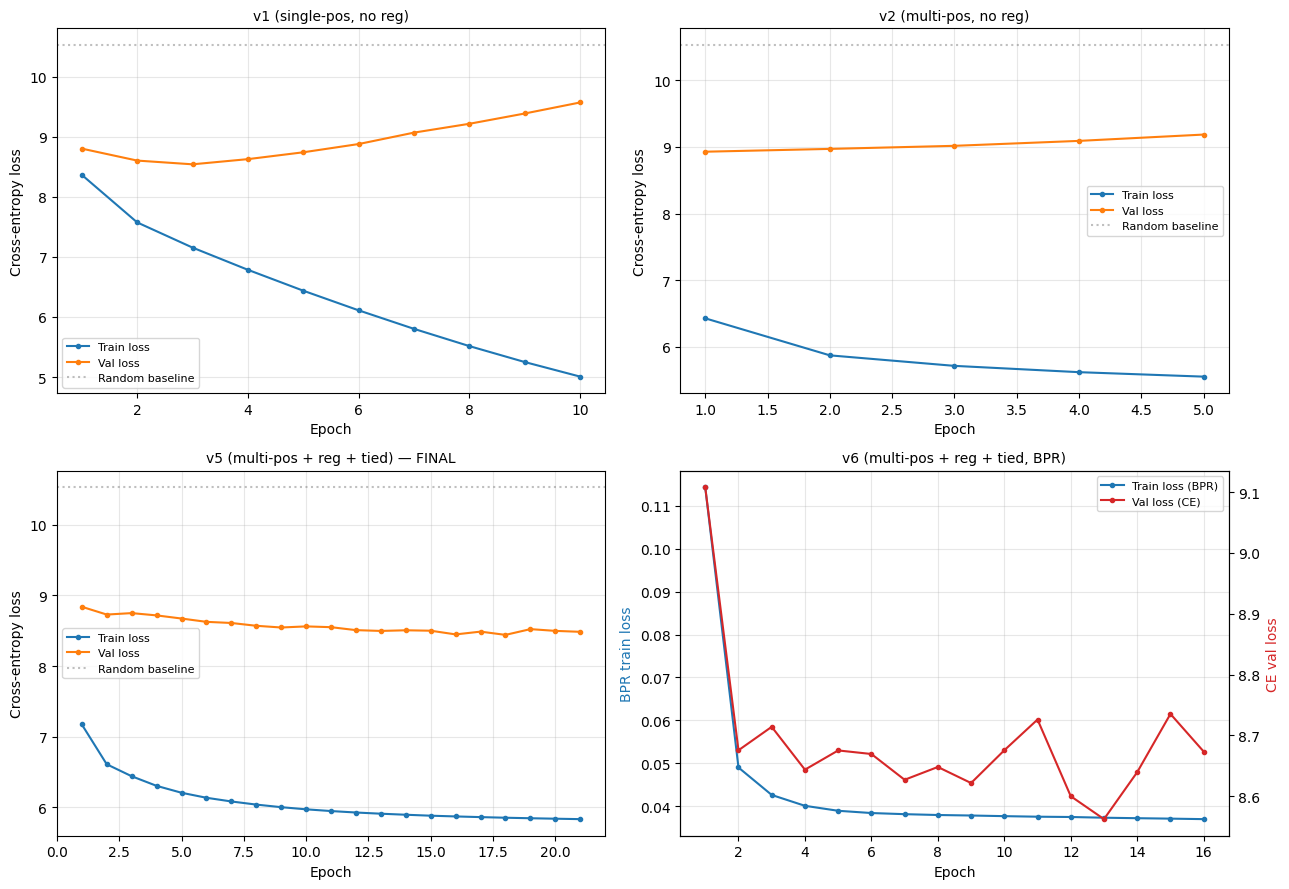

In [12]:
# CELL 12 — Plot 1: per-model train/val loss curves (individual panels, since v6's train loss is on a different scale)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
model_histories = [
    ("v1 (single-pos, no reg)", history_v1, False),
    ("v2 (multi-pos, no reg)", history_v2, False),
    ("v5 (multi-pos + reg + tied) — FINAL", history_v5, False),
    ("v6 (multi-pos + reg + tied, BPR)", history_v6, True),
]

for ax, (name, hist, is_bpr) in zip(axes.flat, model_histories):
    epochs = range(1, len(hist["val_loss"]) + 1)
    if is_bpr:
        ax2 = ax.twinx()
        ax.plot(epochs, hist["train_loss"], color="tab:blue", marker="o", markersize=3, label="Train loss (BPR)")
        ax2.plot(epochs, hist["val_loss"], color="tab:red", marker="o", markersize=3, label="Val loss (CE)")
        ax.set_ylabel("BPR train loss", color="tab:blue")
        ax2.set_ylabel("CE val loss", color="tab:red")
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)
    else:
        ax.plot(epochs, hist["train_loss"], marker="o", markersize=3, label="Train loss")
        ax.plot(epochs, hist["val_loss"], marker="o", markersize=3, label="Val loss")
        ax.axhline(np.log(vocab_size), color="gray", linestyle=":", alpha=0.5, label="Random baseline")
        ax.set_ylabel("Cross-entropy loss")
        ax.legend(fontsize=8)
    ax.set_xlabel("Epoch")
    ax.set_title(name, fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/gru_training_curves.png", dpi=150)
plt.show()

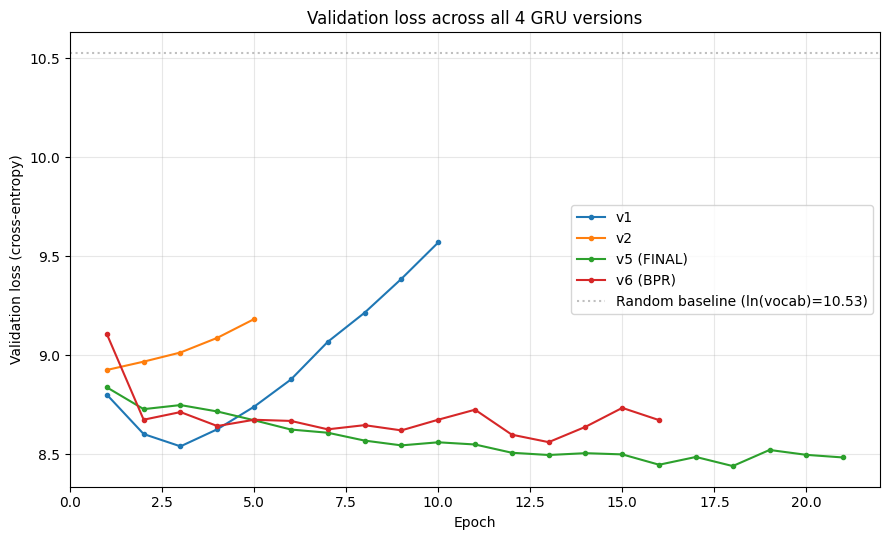

In [13]:
# CELL 13 — Plot 2: val loss only, all 4 models overlaid (all on the CE scale, directly comparable)

fig, ax = plt.subplots(figsize=(9, 5.5))
for name, hist in [("v1", history_v1), ("v2", history_v2), ("v5 (FINAL)", history_v5), ("v6 (BPR)", history_v6)]:
    epochs = range(1, len(hist["val_loss"]) + 1)
    ax.plot(epochs, hist["val_loss"], marker="o", markersize=3, label=name)

ax.axhline(np.log(vocab_size), color="gray", linestyle=":", alpha=0.5,
           label=f"Random baseline (ln(vocab)={np.log(vocab_size):.2f})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation loss (cross-entropy)")
ax.set_title("Validation loss across all 4 GRU versions")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/gru_val_loss_comparison.png", dpi=150)
plt.show()

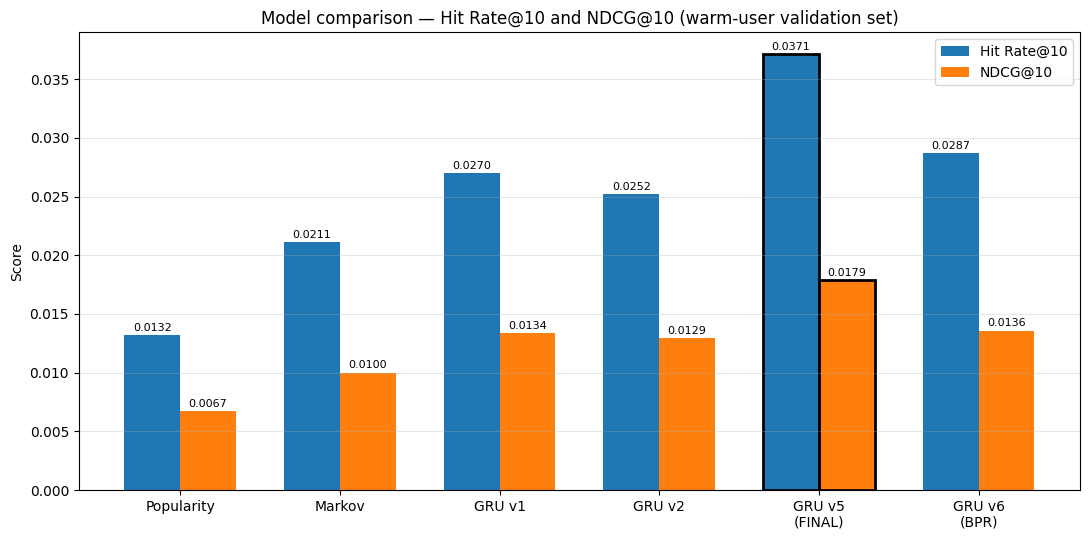

In [14]:
# CELL 14 — Plot 3: Hit Rate@10 / NDCG@10 bar chart, all models including baselines

labels = ["Popularity", "Markov", "GRU v1", "GRU v2", "GRU v5\n(FINAL)", "GRU v6\n(BPR)"]
hit_rates = [popularity_hr10, markov_hr10, hr10_v1, hr10_v2, hr10_v5, hr10_v6]
ndcgs = [popularity_ndcg10, markov_ndcg10, ndcg10_v1, ndcg10_v2, ndcg10_v5, ndcg10_v6]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 5.5))
bars1 = ax.bar(x - width/2, hit_rates, width, label="Hit Rate@10")
bars2 = ax.bar(x + width/2, ndcgs, width, label="NDCG@10")
bars1[4].set_edgecolor("black"); bars1[4].set_linewidth(2)
bars2[4].set_edgecolor("black"); bars2[4].set_linewidth(2)

ax.set_ylabel("Score")
ax.set_title("Model comparison — Hit Rate@10 and NDCG@10 (warm-user validation set)")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend(); ax.grid(alpha=0.3, axis="y")
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.4f}", xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("/kaggle/working/gru_model_comparison.png", dpi=150)
plt.show()

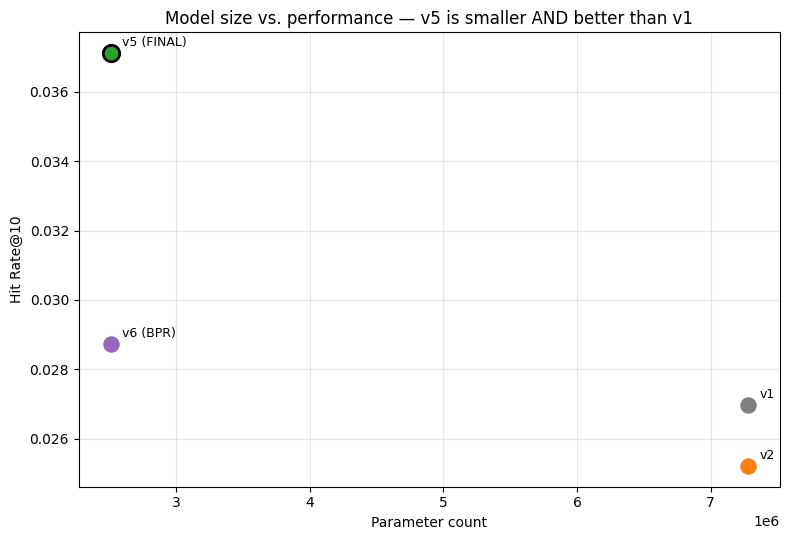

In [15]:
# CELL 15 — Plot 4: parameter count vs. Hit Rate@10 (efficiency view — v5 is both smaller AND better than v1)

fig, ax = plt.subplots(figsize=(8, 5.5))
gru_labels = ["v1", "v2", "v5 (FINAL)", "v6 (BPR)"]
gru_params = [params_v1, params_v2, params_v5, params_v6]
gru_hr = [hr10_v1, hr10_v2, hr10_v5, hr10_v6]
colors = ["tab:gray", "tab:orange", "tab:green", "tab:purple"]

for label, p, hr, c in zip(gru_labels, gru_params, gru_hr, colors):
    ax.scatter(p, hr, s=140, color=c, label=label, edgecolor="black" if "FINAL" in label else None,
               linewidth=2 if "FINAL" in label else 0)
    ax.annotate(label, (p, hr), textcoords="offset points", xytext=(8, 5), fontsize=9)

ax.set_xlabel("Parameter count")
ax.set_ylabel("Hit Rate@10")
ax.set_title("Model size vs. performance — v5 is smaller AND better than v1")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/gru_params_vs_performance.png", dpi=150)
plt.show()

In [16]:
# CELL 16 — Save v5 (final), mappings, and full results including all 4 versions' histories

torch.save(model_v5.state_dict(), "/kaggle/working/gru_model_final.pt")

with open("/kaggle/working/gru_mappings.pkl", "wb") as f:
    pickle.dump({"movie_to_idx": movie_to_idx, "idx_to_movie": idx_to_movie}, f)

gru_final_results = {
    "chosen_model": "GRU v5 (multi-position training + dropout/weight-decay/early-stopping + weight tying)",
    "architecture": {
        "embedding_dim": 64, "hidden_dim": 128, "dropout": 0.3,
        "weight_tying": True, "total_params": params_v5,
    },
    "hit_rate_at_10": round(hr10_v5, 4),
    "ndcg_at_10": round(ndcg10_v5, 4),
    "val_loss": round(min(history_v5["val_loss"]), 4),
    "baseline_comparison": {
        "popularity": {"hit_rate_at_10": popularity_hr10, "ndcg_at_10": popularity_ndcg10},
        "markov": {"hit_rate_at_10": markov_hr10, "ndcg_at_10": markov_ndcg10},
    },
    "experiment_history": {
        "v1_single_position_no_reg": {
            "hit_rate_at_10": round(hr10_v1, 4), "ndcg_at_10": round(ndcg10_v1, 4),
            "val_loss": round(history_v1["val_loss"][-1], 4), "params": params_v1,
            "train_loss_curve": history_v1["train_loss"], "val_loss_curve": history_v1["val_loss"],
        },
        "v2_multipos_no_reg": {
            "hit_rate_at_10": round(hr10_v2, 4), "ndcg_at_10": round(ndcg10_v2, 4),
            "val_loss": round(history_v2["val_loss"][-1], 4), "params": params_v2,
            "train_loss_curve": history_v2["train_loss"], "val_loss_curve": history_v2["val_loss"],
        },
        "v5_final": {
            "hit_rate_at_10": round(hr10_v5, 4), "ndcg_at_10": round(ndcg10_v5, 4),
            "val_loss": round(min(history_v5["val_loss"]), 4), "params": params_v5,
            "train_loss_curve": history_v5["train_loss"], "val_loss_curve": history_v5["val_loss"],
        },
        "v6_bpr_comparison": {
            "hit_rate_at_10": round(hr10_v6, 4), "ndcg_at_10": round(ndcg10_v6, 4),
            "val_loss": round(min(history_v6["val_loss"]), 4), "params": params_v6,
            "train_loss_curve_bpr_scale": history_v6["train_loss"], "val_loss_curve": history_v6["val_loss"],
        },
    },
    "finding": (
        "v1 (single-position, no regularization) overfit substantially "
        "(val loss near the random baseline of ln(vocab_size)). Adding "
        "multi-position training data (v2), then dropout + weight decay + "
        "early stopping + weight tying (v5) closed the train/val gap and "
        "improved Hit Rate@10/NDCG@10 simultaneously, while cutting "
        "parameter count by ~65%. A BPR/negative-sampling variant (v6) "
        "with the same regularized architecture was also tested but "
        "underperformed v5, likely due to uniform (non-hard) negative "
        "sampling providing a weaker training signal than full-softmax "
        "cross-entropy at this data scale."
    ),
    "reproducibility_note": (
        "A global random seed (42) is set at the start of this notebook. "
        "Earlier runs without a fixed seed showed real run-to-run variance "
        "in final Hit Rate@10 (observed range for the v5 architecture: "
        "~3.18%-3.52%) due to unseeded weight initialization, dropout, and "
        "batch shuffling. Report a range rather than a single point estimate "
        "if re-running without this seed."
    ),
}

with open("/kaggle/working/gru_results.json", "w") as f:
    json.dump(gru_final_results, f, indent=2)

print(json.dumps({k: v for k, v in gru_final_results.items() if k != "experiment_history"}, indent=2))
print("\nsaved: gru_model_final.pt, gru_mappings.pkl, gru_results.json, and 4 PNG plots")

{
  "chosen_model": "GRU v5 (multi-position training + dropout/weight-decay/early-stopping + weight tying)",
  "architecture": {
    "embedding_dim": 64,
    "hidden_dim": 128,
    "dropout": 0.3,
    "weight_tying": true,
    "total_params": 2509527
  },
  "hit_rate_at_10": 0.0371,
  "ndcg_at_10": 0.0179,
  "val_loss": 8.4411,
  "baseline_comparison": {
    "popularity": {
      "hit_rate_at_10": 0.0132,
      "ndcg_at_10": 0.0067
    },
    "markov": {
      "hit_rate_at_10": 0.0211,
      "ndcg_at_10": 0.01
    }
  },
  "finding": "v1 (single-position, no regularization) overfit substantially (val loss near the random baseline of ln(vocab_size)). Adding multi-position training data (v2), then dropout + weight decay + early stopping + weight tying (v5) closed the train/val gap and improved Hit Rate@10/NDCG@10 simultaneously, while cutting parameter count by ~65%. A BPR/negative-sampling variant (v6) with the same regularized architecture was also tested but underperformed v5, likely 

In [22]:
# CELL — Example predictions for individual users (movie titles, not just IDs)

movies_master = pd.read_parquet(f"{INTERIM_PATH}/movies_master.parquet")
movieid_to_title = dict(zip(movies_master["movieId"], movies_master["title"]))

def show_example(user_id, model, sequences, ratings_val_warm, movie_to_idx, idx_to_movie,
                  movieid_to_title, k=10, recent_n=10, device="cpu"):
    """
    Prints a user's most recent watch history, the model's top-k predicted
    next movies, and the actual true next movie (if available) — with
    titles instead of raw IDs, for a human-readable sanity check.
    """
    if user_id not in sequences:
        print(f"userId {user_id} not found in sequences (not a warm/trained user).")
        return

    seq = sequences[user_id]
    recent_idxs = seq[-recent_n:]
    recent_titles = [movieid_to_title.get(idx_to_movie[i], f"[unknown id {idx_to_movie[i]}]") for i in recent_idxs]

    print(f"--- userId {user_id} ---")
    print(f"\nrecent watch history (most recent {len(recent_titles)} of {len(seq)} total):")
    for t in recent_titles:
        print(f"  - {t}")

    top_k_idxs = predict_top_k_gru_masked(model, seq, k=k, device=device)
    top_k_titles = [movieid_to_title.get(idx_to_movie[i], f"[unknown id {idx_to_movie[i]}]") for i in top_k_idxs]

    print(f"\ntop-{k} predicted next movies:")
    for rank, t in enumerate(top_k_titles, 1):
        print(f"  {rank}. {t}")

    true_row = (ratings_val_warm[ratings_val_warm["userId"] == user_id]
                .sort_values("timestamp").head(1))
    if not true_row.empty:
        true_movie_id = true_row["movieId"].iloc[0]
        true_title = movieid_to_title.get(true_movie_id, f"[unknown id {true_movie_id}]")
        hit = true_movie_id in [idx_to_movie[i] for i in top_k_idxs]
        print(f"\nactual true next movie (val split): {true_title}")
        print(f"was it in the top-{k}? {'YES' if hit else 'no'}")
    else:
        print("\n(no val-split rating found for this user)")
    print()


# Show a few example users — pick some at random from the warm-user pool
example_users = list(sequences.keys())[:10]
for uid in example_users:
    show_example(uid, model_v5, sequences, ratings_val_warm, movie_to_idx, idx_to_movie,
                 movieid_to_title, k=10, device=device)

--- userId 1 ---

recent watch history (most recent 10 of 70 total):
  - 2046 (2004)
  - Dolls (2002)
  - Look at Me (Comme une image) (2004)
  - Piano Teacher, The (La pianiste) (2001)
  - Idiots, The (Idioterne) (1998)
  - Taxi 2 (2000)
  - Naqoyqatsi (2002)
  - Passion of the Christ, The (2004)
  - Pulp Fiction (1994)
  - Eternal Sunshine of the Spotless Mind (2004)

top-10 predicted next movies:
  1. Amores Perros (Love's a Bitch) (2000)
  2. Lord of the Rings: The Fellowship of the Ring, The (2001)
  3. American Beauty (1999)
  4. Fight Club (1999)
  5. Kill Bill: Vol. 2 (2004)
  6. Memento (2000)
  7. Kill Bill: Vol. 1 (2003)
  8. Shawshank Redemption, The (1994)
  9. Lives of Others, The (Das leben der Anderen) (2006)
  10. Forrest Gump (1994)

(no val-split rating found for this user)

--- userId 2 ---

recent watch history (most recent 10 of 100 total):
  - Shadowlands (1993)
  - Empire of the Sun (1987)
  - K-PAX (2001)
  - Little Women (1994)
  - Rosewood (1997)
  - Who Fram

In [23]:
print(f"v5 (masked)   Hit Rate@10: {hr10_v5_masked:.4f}   NDCG@10: {ndcg10_v5_masked:.4f}")
print(f"v5 (unmasked) Hit Rate@10: {hr10_v5:.4f}   NDCG@10: {ndcg10_v5:.4f}")

NameError: name 'hr10_v5_masked' is not defined

model_v5 parameters: 2,509,527 
epoch 1/30 — train loss: 7.2180 — val loss: 8.7947 — 149.6s
epoch 2/30 — train loss: 6.6449 — val loss: 8.7614 — 150.8s
epoch 3/30 — train loss: 6.4580 — val loss: 8.7272 — 150.5s
epoch 4/30 — train loss: 6.3253 — val loss: 8.7263 — 152.4s
epoch 5/30 — train loss: 6.2302 — val loss: 8.7390 — 151.7s
epoch 6/30 — train loss: 6.1586 — val loss: 8.6326 — 150.4s
epoch 7/30 — train loss: 6.0998 — val loss: 8.6263 — 152.3s
epoch 8/30 — train loss: 6.0520 — val loss: 8.6339 — 160.2s
epoch 9/30 — train loss: 6.0131 — val loss: 8.5909 — 158.0s
epoch 10/30 — train loss: 5.9810 — val loss: 8.4971 — 160.1s
epoch 11/30 — train loss: 5.9545 — val loss: 8.5237 — 158.3s
epoch 12/30 — train loss: 5.9329 — val loss: 8.5101 — 161.9s
epoch 13/30 — train loss: 5.9140 — val loss: 8.4891 — 159.8s
epoch 14/30 — train loss: 5.8988 — val loss: 8.4907 — 160.2s
epoch 15/30 — train loss: 5.8855 — val loss: 8.4499 — 155.9s
epoch 16/30 — train loss: 5.8750 — val loss: 8.5032 — 159.5s
e

evaluated on 5118 users in 11.3s

GRU v5 (multi-pos + regularized + tied) Hit Rate@10: 0.0352
GRU v5 (multi-pos + regularized + tied) NDCG@10: 0.0175

--- Full comparison ---
Model                                   Hit Rate@10   NDCG@10   Val Loss  Params
Popularity                              0.0132        0.0067    --        --
Markov                                  0.0211        0.01      --        --
GRU v1 (single-pos, overfit)            0.0283        0.0146    9.535     7.28M
GRU v5 (+ tied weights)                 0.0352        0.0175    8.4333    2.51M


{
  "chosen_model": "GRU v5 (multi-position training + dropout/weight-decay/early-stopping + weight tying)",
  "architecture": {
    "embedding_dim": 64,
    "hidden_dim": 128,
    "dropout": 0.3,
    "weight_tying": true,
    "total_params": 2509527
  },
  "hit_rate_at_10": 0.0318,
  "ndcg_at_10": 0.0157,
  "val_loss": 8.4333,
  "experiment_history": {
    "v1_single_position_overfit": {
      "hit_rate_at_10": 0.0283,
      "ndcg_at_10": 0.0146,
      "val_loss": 9.535,
      "params": 7280151
    },
    "v2_uniform_multipos_unregularized": {
      "hit_rate_at_10": 0.026,
      "ndcg_at_10": 0.013,
      "val_loss": 9.1588
    },
    "v3_weighted_multipos_unregularized": {
      "hit_rate_at_10": 0.0258,
      "ndcg_at_10": 0.0126,
      "val_loss": 9.3043
    },
    "v4_multipos_regularized_early_stopped": {
      "hit_rate_at_10": null,
      "ndcg_at_10": null,
      "val_loss": 8.4806,
      "params": 7280151
    },
    "v5_final_multipos_regularized_tied": {
      "hit_rate_at_

model_v6 parameters: 2,509,527
epoch 1/30 — BPR train loss: 0.1161 — val loss (CE, for comparability): 9.0021 — 147.7s
epoch 2/30 — BPR train loss: 0.0493 — val loss (CE, for comparability): 8.6892 — 146.8s
epoch 3/30 — BPR train loss: 0.0426 — val loss (CE, for comparability): 8.7139 — 145.0s
epoch 4/30 — BPR train loss: 0.0402 — val loss (CE, for comparability): 8.6868 — 145.5s
epoch 5/30 — BPR train loss: 0.0393 — val loss (CE, for comparability): 8.6432 — 144.4s
epoch 6/30 — BPR train loss: 0.0385 — val loss (CE, for comparability): 8.6248 — 143.1s
epoch 7/30 — BPR train loss: 0.0381 — val loss (CE, for comparability): 8.5704 — 144.1s
epoch 8/30 — BPR train loss: 0.0378 — val loss (CE, for comparability): 8.7244 — 142.9s
epoch 9/30 — BPR train loss: 0.0376 — val loss (CE, for comparability): 8.6401 — 144.7s
epoch 10/30 — BPR train loss: 0.0375 — val loss (CE, for comparability): 8.5679 — 144.0s
epoch 11/30 — BPR train loss: 0.0373 — val loss (CE, for comparability): 8.6426 — 145.2s

evaluated on 5118 users in 10.9s

GRU v6 (BPR + negative sampling) Hit Rate@10: 0.0250
GRU v6 (BPR + negative sampling) NDCG@10: 0.0110

--- Full comparison ---
Model                                   Hit Rate@10   NDCG@10   Val Loss  Params
Popularity                              0.0132        0.0067    --        --
Markov                                  0.0211        0.01      --        --
GRU v1 (single-pos, overfit)            0.0283        0.0146    9.535     7.28M
GRU v5 (multipos+reg+tied, CE loss)     0.0318        0.0157    8.4333    2.51M
GRU v6 (multipos+reg+tied, BPR loss)    0.0250        0.0110    ?         2509527


In [25]:
# CELL — Update saved results with the masked (final, correct) evaluation numbers

gru_final_results["hit_rate_at_10"] = round(hr10_v5_masked, 4)
gru_final_results["ndcg_at_10"] = round(ndcg10_v5_masked, 4)
gru_final_results["seen_item_masking"] = {
    "applied": True,
    "note": "Predictions mask out movies already in the user's watch history before "
            "taking top-k. Without this, a substantial share of top-10 slots were "
            "occupied by already-watched titles rather than genuine new recommendations.",
    "unmasked_hit_rate_at_10": round(hr10_v5, 4),
    "unmasked_ndcg_at_10": round(ndcg10_v5, 4),
    "masked_hit_rate_at_10": round(hr10_v5_masked, 4),
    "masked_ndcg_at_10": round(ndcg10_v5_masked, 4),
}

with open("/kaggle/working/gru_results.json", "w") as f:
    json.dump(gru_final_results, f, indent=2)

print("updated gru_results.json with masked (final) evaluation numbers")
print(json.dumps(gru_final_results["seen_item_masking"], indent=2))

updated gru_results.json with masked (final) evaluation numbers
{
  "applied": true,
  "note": "Predictions mask out movies already in the user's watch history before taking top-k. Without this, a substantial share of top-10 slots were occupied by already-watched titles rather than genuine new recommendations.",
  "unmasked_hit_rate_at_10": 0.0371,
  "unmasked_ndcg_at_10": 0.0179,
  "masked_hit_rate_at_10": 0.0514,
  "masked_ndcg_at_10": 0.0256
}
